# Import


In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
import networkx as nx
from scipy import linalg
from inspect import getmembers
!pip install qiskit qiskit-aer
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.quantum_info import random_unitary
from qiskit.compiler import transpile
from qiskit.quantum_info import state_fidelity
from qiskit.circuit.library import QFTGate
from qiskit.circuit.library import MCXGate
import time


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


# Utils


## Grafo


In [4]:
def generateSparseGraphWithNNodes(numberOfNodes):
    """
    Genera la matrice Laplaciana di un grafo connesso sparso dove il grado massimo
    è al più log2(numero di nodi) e il grado minimo è almeno 1.
    """
    import random
    d_max = int(math.log2(numberOfNodes))

    # Cerchiamo di generare un grafo che sia connesso e rispetti il vincolo
    # Usiamo un approccio iterativo per garantire la connessione
    connected = False
    attempts = 0
    while not connected and attempts < 100:
        # Probabilità bassa per mantenere il grafo sparso
        p = (d_max / numberOfNodes) * 0.8
        G = nx.fast_gnp_random_graph(numberOfNodes, p, seed=42+attempts)

        # Verifichiamo se il grado massimo è rispettato e se è connesso
        current_max_degree = max([d for n, d in G.degree()])
        if current_max_degree <= d_max and nx.is_connected(G):
            connected = True
        else:
            # Se non è connesso o grado troppo alto, proviamo a manipolarlo o rigenerarlo
            attempts += 1

    if not connected:
        # Fallback: crea un grafo a ciclo (grado 2) e aggiungi archi casuali
        G = nx.cycle_graph(numberOfNodes)
        nodes = list(G.nodes())
        for _ in range(numberOfNodes):
            u, v = random.sample(nodes, 2)
            if G.degree(u) < d_max and G.degree(v) < d_max:
                G.add_edge(u, v)

    L = nx.laplacian_matrix(G).toarray()
    actual_max = max([d for n, d in G.degree()])
    print(f"Grafo generato: N={numberOfNodes}, Grado Max={actual_max} (Limite={d_max}), Connesso={nx.is_connected(G)}")
    return L

def get_max_degree_from_laplacian(L):
    """
    Restituisce il grado massimo del grafo data la matrice Laplaciana L.
    """
    # I gradi dei nodi corrispondono agli elementi sulla diagonale della Laplaciana
    degrees = np.diag(L)
    return np.max(degrees)


def drawGraph(L, seed=42):
  # Ricostruiamo la matrice di adiacenza dalla Laplaciana
  # A = D - L. Poiché gli elementi fuori diagonale di L sono -1 se c'è un arco,
  # l'adiacenza ha 1 dove L ha valori negativi.
  adj = -L.copy()
  np.fill_diagonal(adj, 0)
  adj[adj > 0] = 1
  adj[adj < 0] = 0

  # Creazione del grafo da matrice di adiacenza
  G = nx.from_numpy_array(adj)

  plt.figure(figsize=(8, 6))
  pos = nx.spring_layout(G, seed=seed)

  nx.draw(G, pos, with_labels=True, node_color='skyblue',
          node_size=500, edge_color='gray', font_size=10, font_weight='bold')

  plt.title(f"Visualizzazione del Grafo dalla Matrice Laplaciana")


  plt.show()




def get_edge_contributions(L):
  """
  Data una matrice Laplaciana, restituisce una lista di matrici,
  una per ogni arco, che rappresentano il contributo di quell'arco alla Laplaciana totale.
  """
  n = L.shape[0]
  contributions = []

  # Iteriamo sulla parte triangolare superiore (esclusa la diagonale)
  # per trovare gli archi (dove L[i, j] < 0)
  for i in range(n):
    for j in range(i + 1, n):
      if L[i, j] < 0:
        # Trovato un arco tra i e j
        # La matrice di contributo per un arco (i, j) ha:
        # +1 in (i,i) e (j,j), -1 in (i,j) e (j,i)
        # Moltiplichiamo per il peso assoluto se i pesi non sono unitari
        weight = abs(L[i, j])
        edge_l = np.zeros((n, n))
        edge_l[i, i] = weight
        edge_l[j, j] = weight
        edge_l[i, j] = -weight
        edge_l[j, i] = -weight

        contributions.append(edge_l)

  return np.array(contributions)



def removeEdge(l, indexA, indexB):

  if (   l[indexA][indexB] == -1 and l[indexB][indexA] == -1 ):

    l[indexA][indexA] -= 1
    l[indexA][indexB] += 1
    l[indexB][indexA] += 1
    l[indexB][indexB] -= 1
    return l
  else:
    print(f"non esiste un arco tra {indexA} ed  {indexB}")
    return l


def addEdge(l, indexA, indexB):

#sommo lungo la diagonale, decremento fuori dalla diagonale

  l[indexA][indexA] += 1
  l[indexA][indexB] -= 1
  l[indexB][indexA] -= 1
  l[indexB][indexB] += 1
  return l




def getFiedlerVector(L):
  lambda2, v2 = get_fiedler_properties(L)
  return v2

def getFiedlerValue(L):
  lambda2, v2 = get_fiedler_properties(L)
  return lambda2

def printEigenValues(L):

  eigenvalues, eigenvectors = linalg.eigh(L)
  print("Eigenvalues:")
  # Set print options to suppress scientific notation and set precision
  np.set_printoptions(suppress=True, precision=4)
  print(eigenvalues)
  # Reset print options to default to avoid affecting other prints
  np.set_printoptions(suppress=False, precision=8)



def find_edge_index(laplaciana, node_u, node_v):
    """
    Data la lista di matrici di contributo degli archi e gli indici di due nodi,
    restituisce l'indice della matrice corrispondente nella lista.
    """
    edgeContributions = get_edge_contributions(laplaciana)

    for idx, matrix in enumerate(edgeContributions):
        # In una matrice di contributo di un arco (u, v), l'elemento (u, v)
        # (e simmetricamente v, u) è negativo (tipicamente -1).
        if matrix[node_u, node_v] < 0:
            return idx
    return None

## Generazione circuito contributo arco

In [5]:
def build_custom_cnot(pattern):
    """
    Costruisce un circuito con un gate multi-controllato basato su un pattern.
    1  -> Controllo sullo stato |1>
    0  -> Controllo sullo stato |0>
    -1 -> Qubit Target
    """
    num_qubits = len(pattern)
    qc = QuantumCircuit(num_qubits)

    controls = []
    target = None
    zeros = []

    for idx, val in enumerate(pattern):
        if val == 1:
            controls.append(idx)
        elif val == 0:
            controls.append(idx)
            zeros.append(idx)
            # Applichiamo X per rendere il controllo attivo sullo stato 0
            qc.x(idx)
        elif val == -1:
            target = idx

    if target is None:
        raise ValueError("Nessun qubit target (-1) trovato nel pattern.")

    # Applichiamo il gate multi-controllato (MCX)
    if controls:
        qc.mcx(controls, target)
    else:
        qc.x(target)

    # Uncompute degli X per ripristinare i qubit di controllo
    for idx in zeros:
        qc.x(idx)

    return qc

def get_non_trivial_changed_states(matrix):
    matrix = np.array(matrix)
    n = matrix.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            if matrix[i, j] == -1:
                return i, j

    raise ValueError("Nessun arco trovato.")

def int_to_binary_string(number, num_bits):
    """
    Converts an integer to a binary string with a fixed length.
    Example: int_to_binary_string(3, 4) -> '0011'
    """
    # The format string f'0{num_bits}b' pads with zeros to the left
    return format(number, f'0{num_bits}b')


def generate_gray_code_path_pattern_lsb(start_str, end_str):
    """
    Genera una lista di pattern partendo dal bit meno significativo (LSB).
    Assume che l'LSB sia l'ultimo carattere della stringa (destra).
    """
    if len(start_str) != len(end_str):
        raise ValueError("Le stringhe devono avere la stessa lunghezza.")

    patterns = []
    current_state = list(start_str)
    target = list(end_str)

    # Identifichiamo gli indici dei bit differenti
    # Invertiamo l'ordine per partire dall'indice più alto (LSB)
    diff_indices = [idx for idx, (s, e) in enumerate(zip(start_str, end_str)) if s != e]
    diff_indices.reverse()

    for idx_to_change in diff_indices:
        # Creiamo il pattern per lo step attuale
        pattern = [int(b) for b in current_state]
        pattern[idx_to_change] = -1

        patterns.append(pattern)

        # Aggiorniamo lo stato per il prossimo step
        current_state[idx_to_change] = target[idx_to_change]

    return patterns


def getCnotSequenceCircuit(edgeMatrix, showCircuit=False, showGrayCode=False):


  num_qubits = int(np.log2(edgeMatrix.shape[0]))
  changed_states = get_non_trivial_changed_states(edgeMatrix)

  #arco che va dal nodo:
  firstIndex = changed_states[0]
  #al nodo:
  secondIndex = changed_states[1]

  firstIndexBinary = int_to_binary_string(firstIndex, num_qubits)
  secondIndexBinary = int_to_binary_string(secondIndex, num_qubits)

  grayCode = generate_gray_code_path_pattern_lsb(firstIndexBinary, secondIndexBinary)


  # Eliminiamo l'ultimo elemento
  lastPattern = grayCode[-1]
  grayCodeWithoutTail = grayCode[:-1]



  if ( showGrayCode):
    print("Gray Code:")
    print(grayCodeWithoutTail)

  # Creiamo un circuito temporaneo per la sequenza di CNOT
  controlledNotCircuit = QuantumCircuit(num_qubits)
  for pattern in grayCodeWithoutTail:
      controlledNotCircuit.compose(build_custom_cnot(pattern), inplace=True)

  if ( showCircuit):
    print("Seqeunza di CNOT")
    print(controlledNotCircuit.draw(output='text'))

  return controlledNotCircuit, lastPattern

def computeTwoDimensionRotationAndPhaseUnitary(tau):
    # Definiamo direttamente la matrice 2x2
    # La struttura desiderata sembra essere:
    # [[diag, nonDiag],
    #  [nonDiag, diag]]

    diag = np.exp(1j * tau) * np.cos(tau)
    non_diag = np.exp(1j * tau) * (-1j) * np.sin(tau)

    matrix = np.array([
        [diag, non_diag],
        [non_diag, diag]
    ])

    return matrix







def apply_custom_controlled_unitary(unitary_matrix, pattern):
    """
    Applica una matrice unitaria 2x2 basata su un pattern di controllo.
    1  -> Controllo sullo stato |1>
    0  -> Controllo sullo stato |0>
    -1 -> Qubit Target per l'unitaria U
    """
    if unitary_matrix.shape != (2, 2):
        raise ValueError("La matrice deve essere 2x2.")

    num_qubits = len(pattern)
    qc = QuantumCircuit(num_qubits)

    controls = []
    target = None
    zeros = []

    # Identificazione ruoli basata sul pattern
    for idx, val in enumerate(pattern):
        if val == 1:
            controls.append(idx)
        elif val == 0:
            controls.append(idx)
            zeros.append(idx)
            qc.x(idx)
        elif val == -1:
            target = idx

    if target is None:
        raise ValueError("Nessun qubit target (-1) trovato nel pattern.")

    # Creazione del gate unitario
    u_gate = UnitaryGate(unitary_matrix, label="U")

    # Applicazione del gate controllato o semplice
    if controls:
        controlled_u = u_gate.control(len(controls))
        qc.append(controlled_u, controls + [target])
    else:
        qc.append(u_gate, [target])

    # Ripristino dei qubit (uncompute degli X)
    for idx in zeros:
        qc.x(idx)

    return qc

def compute_two_level_unitary(M, tau):
    """
    Calcola exp(i*M*t) per una matrice che soddisfa M^2 = 2M.
    """
    i, j = get_non_trivial_changed_states(M)

    # Specifichiamo dtype=complex per evitare il casting a real
    identity = np.eye(M.shape[0], dtype=complex)

    diag = np.exp(1j * tau) * np.cos(tau)
    non_diag = np.exp(1j * tau) * (-1j) * np.sin(tau)

    identity[i, i] = diag
    identity[j, j] = diag

    identity[i, j] = non_diag
    identity[j, i] = non_diag

    return identity


def getCircuitForEdgeMatrixExponentiation(edgeMatrix, tau, showCircuit=False):
  num_qubits = int(np.log2(edgeMatrix.shape[0]))
  qc = QuantumCircuit(num_qubits)

  # 1. Aggiungiamo i CNOT iniziali
  controlledNotCircuit, lastPattern = getCnotSequenceCircuit(edgeMatrix)
  qc.compose(controlledNotCircuit, inplace=True)

  qc.barrier()


  # 1.1 calcolo unitaria bidimensionale
  matrix = computeTwoDimensionRotationAndPhaseUnitary(tau)

  # 2. Aggiungiamo l'unitaria controllata (LSB target)
  # Passiamo la matrice calcolata
  qc.compose(apply_custom_controlled_unitary( matrix, lastPattern), inplace=True)

  qc.barrier()


  # 3. Aggiungiamo l'inversa dei CNOT
  qc.compose(controlledNotCircuit.inverse(), inplace=True)

  if showCircuit:
      print("\nFinal Circuit (CNOTs -> U -> inverse CNOTs):")
      print(qc.draw(output='text'))

  return qc

## Logica rimozione arco

In [6]:


def create_nor_circuit(qc: QuantumCircuit, n: int, start_index: int ):
    """
    Modifica un circuito esistente qc applicando gate su n qubit partendo da start_index sul qubit indicato su target_index:
    - X gate sui primi n-1 qubit del blocco
    """
    if n < 1:
        raise ValueError("Il numero di qubit n deve essere almeno 1.")

    # Calcolo degli indici relativi al circuito globale
    block_indices = list(range(start_index, start_index + n))
    control_indices = block_indices[:-1]
    target_index = block_indices[-1]

    # Applica X gate sui primi n-1 qubit del blocco
    if n > 1:
        for i in control_indices:
            qc.x(i)

        # Gate X sull'ultimo qubit controllato dai primi n-1 del blocco
        gate = MCXGate(num_ctrl_qubits=len(control_indices))
        qc.append(gate, control_indices + [target_index])
        # de commenta se quello sopra non va qc.mcx(control_indices, target_index)

        # Uncompute degli X gate sui controlli
        for i in control_indices:
            qc.x(i)

    return qc


def apply_bitstring_controlled_x(qc, bitstring, startQubit, target_qubit):
    """
    Applica un gate X sul target_qubit controllato dai control_qubits
    basandosi su una specifica stringa di bit.
    """
    # 1. Applica gate X dove la stringa di bit ha uno '0'
    for i, bit in enumerate(bitstring):
        if bit == '0':
            qc.x(i + startQubit)

    # 2. Applica il gate Multi-Controlled X
    # FIX: Convert range to list to avoid TypeError in Qiskit concatenation
    control_indices = list(range(startQubit, startQubit + len(bitstring)))

    gate = MCXGate(num_ctrl_qubits=len(control_indices))
    qc.append(gate, control_indices + [target_qubit])

    #de commenta se quello sopra non vaqc.mcx(control_indices, target_qubit)

    # 3. Uncompute: riapplica gate X dove c'era lo '0' per ripristinare lo stato
    for i, bit in enumerate(bitstring):
        if bit == '0':
            qc.x(i + startQubit)

##

# Costruzione circuito

## Helper circuito

### Grover

#### Grover stima lambda due

In [7]:
def optimal_grover_iterations(n):
    """k = (pi/4) sqrt(N/M) sullo spazio degli autovettori.
       N = n. nodi (init bilanciata = uniforme sugli autovettori)
       M = n. autovalori 0 < lambda < soglia (dallo spettro classico)."""
    #eig = np.linalg.eigvalsh(laplacian)
    #M = int(np.sum((eig > 1e-9) & (eig < target_threshold)))
    #if M == 0 or M >= N:
    #    return 0
    M=1
    theta = np.arcsin(np.sqrt(M / n))          # esatto; ~ sqrt(M/N) per M<<N

    groverIterations = max(1, round(np.pi / (4 * theta) - 0.5))
    return  groverIterations


def build_grover_operator(laplacian, precision_qubits, trotter_steps,
                            edgesToRemove , target_threshold ):
    """
    Operatore G = U_pe · U_in · Phase · U_in† · U_pe† · Of
    Usa buildHamiltonianSimulationGate per la simulazione Hamiltoniana.
    """

    n_nodes = laplacian.shape[0]
    num_state_qubits = int(np.log2(n_nodes))
    edge_contributions = get_edge_contributions(laplacian)
    edgeIndexesLength = int(np.ceil(np.log2(len(edge_contributions))))
    scaling_factor= get_max_degree_from_laplacian(laplacian)*2
    numberOfEdgesToRemove = len(edgesToRemove)

    # Calcolo qubit totali (uguale a buildHamiltonianSimulationGate)
    internal_ancillas = (edgeIndexesLength * numberOfEdgesToRemove) + numberOfEdgesToRemove + 1
    total_q = precision_qubits + (2 * num_state_qubits) + internal_ancillas

    prec_range = list(range(precision_qubits))
    state_start = precision_qubits
    state_indices = list(range(state_start, state_start + num_state_qubits))
    copy_indices = list(range(state_start + num_state_qubits, state_start + 2 * num_state_qubits))
    ancilla_start = precision_qubits + 2 * num_state_qubits
    all_target_qubits = list(range(total_q))

    G = QuantumCircuit(total_q, name="G")

    # --- Of: Oracle sui qubit di precisione ---
    oracle = QuantumCircuit(precision_qubits, name="Of")
    for i in range(1, 2**precision_qubits):
        phase = i / (2**precision_qubits)
        est_val = phase * scaling_factor
        if est_val < target_threshold - 1e-5:
            bitstring = format(i, f'0{precision_qubits}b')[::-1]
            for idx, bit in enumerate(bitstring):
                if bit == '0':
                    oracle.x(idx)
            oracle.h(precision_qubits - 1)
            oracle.mcx(list(range(precision_qubits - 1)), precision_qubits - 1)
            oracle.h(precision_qubits - 1)
            for idx, bit in enumerate(bitstring):
                if bit == '0':
                    oracle.x(idx)
    G.append(oracle.to_gate(), prec_range)

    # --- U_PE† (dagger) : usa buildHamiltonianSimulationGate con dagger=True ---

    G.append(QFTGate(precision_qubits), prec_range)
    computePowerOfUnitaries(G, precision_qubits, total_q, laplacian,
                           trotter_steps, numberOfEdgesToRemove, dagger=True)
    G.h(prec_range)

    # --- U_in† : inverso dell'inizializzazione bilanciata ---
    for i in reversed(range(num_state_qubits)):
        G.cx(state_indices[i], copy_indices[i])
        G.h(state_indices[i])

    # --- Phase: 2|0⟩⟨0| - I su tutti i qubit logici ---
    logical_qubits = prec_range + state_indices + copy_indices
    n_logical = len(logical_qubits)
    phase_circ = QuantumCircuit(n_logical, name="Phase")
    phase_circ.x(list(range(n_logical)))
    phase_circ.h(n_logical - 1)
    phase_circ.mcx(list(range(n_logical - 1)), n_logical - 1)
    phase_circ.h(n_logical - 1)
    phase_circ.x(list(range(n_logical)))
    G.append(phase_circ.to_gate(), logical_qubits)

    # --- U_in : reinizializzazione bilanciata ---
    for i in range(num_state_qubits):
        G.h(state_indices[i])
        G.cx(state_indices[i], copy_indices[i])

    # --- U_PE forward ---
    G.h(prec_range)
    computePowerOfUnitaries(G, precision_qubits, total_q, laplacian,
                           trotter_steps, numberOfEdgesToRemove, dagger=False)
    G.append(QFTGate(precision_qubits).inverse(), prec_range)


    return G

### Rimozione arco

quando grover sarà doppio, cambiare con inizializzazione hadamard

In [9]:
def edgesToRemoveInitialization(startIndex, edgesToRemove, qc, edgeIndexesLength):

  for edgeToRemoveIntString in edgesToRemove:
    if edgeToRemoveIntString != 0 and np.floor(np.log2(edgeToRemoveIntString)) >= edgeIndexesLength:
      raise ValueError(f"the indexes {edgeToRemoveIntString} needs more bit to be expressed")
    for edgeToRemoveBinaryValue in int_to_binary_string(edgeToRemoveIntString, edgeIndexesLength):
      if edgeToRemoveBinaryValue == '1':
        qc.x(startIndex)
      startIndex += 1

### Qpe

In [10]:



def buildHamiltonianSimulationGate(laplacian, precision_qubits, trotter_steps, numberOfEdgesToRemove, j_index, dagger:False):
    """
    Crea un gate che incapsula la simulazione Hamiltoniana per il j-esimo qubit di precisione.
    """
    n_nodes = laplacian.shape[0]
    num_state_qubits = int(np.log2(n_nodes))
    edge_contributions = get_edge_contributions(laplacian)
    edgeIndexesLength = int(np.ceil(np.log2(len(edge_contributions))))

    # Calcolo parametri fisici
    max_deg = get_max_degree_from_laplacian(laplacian)
    time_base = np.pi / max_deg
    total_time_j = time_base * (2**j_index)
    steps = trotter_steps * (2**j_index)
    tau = total_time_j / steps

    # Registri interni alla definizione del gate
    internal_ancillas = (edgeIndexesLength * numberOfEdgesToRemove) + numberOfEdgesToRemove + 1
    total_internal_qubits = precision_qubits + (2 * num_state_qubits) + internal_ancillas

    inner_qc = QuantumCircuit(total_internal_qubits, name=f"Hamiltonian_Step_2^{j_index}")

    state_indices = list(range(precision_qubits, precision_qubits+num_state_qubits))
    startIndexLength = precision_qubits + (2 * num_state_qubits)
    flagStart = startIndexLength + (edgeIndexesLength * numberOfEdgesToRemove)
    global_ancilla = total_internal_qubits - 1

    for step in range(steps):
        for idx, edge_L in enumerate(edge_contributions):
            cnotCircuit, lastPattern = getCnotSequenceCircuit(edge_L, showCircuit=False, showGrayCode=False)
            local_U = computeTwoDimensionRotationAndPhaseUnitary(tau)
            edge_U_circuit = apply_custom_controlled_unitary(local_U, lastPattern)

            controlled_edge_U = edge_U_circuit.to_gate(label=f"E{idx}").control(2)

            controls = [global_ancilla, j_index]

            inner_qc.append(cnotCircuit.to_gate(), state_indices)
            if numberOfEdgesToRemove > 0:
                for i in range(numberOfEdgesToRemove):
                    apply_bitstring_controlled_x(inner_qc, int_to_binary_string(idx, edgeIndexesLength),
                                                 startQubit=startIndexLength + (edgeIndexesLength * i),
                                                 target_qubit=flagStart + i)
                create_nor_circuit(inner_qc, n=numberOfEdgesToRemove + 1, start_index=flagStart)



                inner_qc.append(controlled_edge_U, controls + state_indices)

                create_nor_circuit(inner_qc, n=numberOfEdgesToRemove + 1, start_index=flagStart)
                for i in reversed(range(numberOfEdgesToRemove)):
                    apply_bitstring_controlled_x(inner_qc, int_to_binary_string(idx, edgeIndexesLength),
                                                 startQubit=startIndexLength + (edgeIndexesLength * i),
                                                 target_qubit=flagStart + i)
            else:
                inner_qc.append(controlled_edge_U, controls + state_indices)

            inner_qc.append(cnotCircuit.inverse().to_gate(), state_indices)

    if dagger==True:
        return inner_qc.inverse().to_gate(label=f"U^2^{j_index} dagger")
    return inner_qc.to_gate(label=f"U^2^{j_index}")




def computePowerOfUnitaries(qc, precision_qubits, total_qubits ,laplacian, trotter_steps, numberOfEdgesToRemove, dagger):
  target_qubits = list(range(0, total_qubits))
  for j in range(precision_qubits):
        unitaryExponentiated = buildHamiltonianSimulationGate(laplacian, precision_qubits, trotter_steps, numberOfEdgesToRemove, j, dagger)
        qc.append(unitaryExponentiated,  target_qubits)




## Circuito

In [11]:
def buildCircuit(laplacian, precision_qubits, trotter_steps,edgesToRemove = None, targetThreshold = None, showCircuit=True):
    """
    Versione snella del QPE con blocchi Hamiltonian simulation.
    """
    n_nodes = laplacian.shape[0]
    num_state_qubits = int(np.log2(n_nodes))
    edge_contributions = get_edge_contributions(laplacian)
    edgeIndexesLength = int(np.ceil(np.log2(len(edge_contributions))))

    numberOfEdgesToRemove = len(edgesToRemove)

    if numberOfEdgesToRemove > len(edge_contributions):
      raise ValueError("Non ci sono abbastanza archi da rimuovere")

    total_qubits = int(precision_qubits + 2*num_state_qubits + (edgeIndexesLength * numberOfEdgesToRemove) + numberOfEdgesToRemove + 1)
    qc = QuantumCircuit(total_qubits, precision_qubits)

    if edgesToRemove is not None and numberOfEdgesToRemove>0 :
      edgesToRemoveInitialization(precision_qubits + 2*num_state_qubits ,edgesToRemove, qc, edgeIndexesLength)


    for i in range(num_state_qubits):
        qc.h(precision_qubits + i)
        qc.cx(precision_qubits + i, precision_qubits + num_state_qubits + i)
    qc.barrier()

    if numberOfEdgesToRemove == 0:
      qc.x(total_qubits - 1)

    qc.h(range(precision_qubits))
    qc.barrier()




    computePowerOfUnitaries(qc,precision_qubits,total_qubits, laplacian, trotter_steps, numberOfEdgesToRemove, dagger=False  )



    iqft = QFTGate(precision_qubits).inverse()
    qc.append(iqft, range(precision_qubits))


    # Step 3 — ripetizioni grover
    if targetThreshold is not None:


        grover_iterations = optimal_grover_iterations( num_state_qubits)
        G = build_grover_operator(laplacian,
                                  precision_qubits,
                                  trotter_steps,
                                  edgesToRemove,
                                  targetThreshold)

        for _ in range(grover_iterations):
          qc.append(G.to_gate(), range(total_qubits))
        qc.barrier()

    qc.measure(range(precision_qubits), range(precision_qubits))




    if showCircuit: display(qc.draw(fold=-1))
    return qc

# Esecuzione circuito e output

## Output


In [12]:
def return_most_frequent_qpe_phase(qc, shots=10):
    """
    Esegue il circuito QPE e restituisce la stringa di bit più frequente
    corrispondente alla fase misurata.
    """
    from qiskit_aer import AerSimulator

    # Inizializza il simulatore
    backend = AerSimulator()

    # Transpile and executing
    transpiled_qc = transpile(qc, backend)
    job = backend.run(transpiled_qc, shots=shots)
    counts = job.result().get_counts()

    # Trova la stringa di bit con il maggior numero di occorrenze
    most_frequent_bits = max(counts, key=counts.get)

    return most_frequent_bits



###Metodi di utilità QPE

def binary_to_decimal_fraction(bitstring):
    """
    Converte una stringa di bit in un decimale frazionario.
    La prima cifra vale 2^-1, la seconda 2^-2, ecc.
    """
    decimal = 0.0
    for i, bit in enumerate(bitstring):
        if bit == '1':
            decimal += 2**(-(i + 1))
    return decimal

def return_all_qpe_phase_measured(qc, shots=10):
    """
    Esegue il circuito QPE e restituisce la stringa di bit più frequente
    corrispondente alla fase misurata.
    """
    from qiskit_aer import AerSimulator

    # Inizializza il simulatore
    backend = AerSimulator()

    # Transpila ed esegue
    transpiled_qc = transpile(qc, backend)
    job = backend.run(transpiled_qc, shots=shots)
    counts = job.result().get_counts()

    # Trova la stringa di bit con il maggior numero di occorrenze
    print(counts)

    return counts



def process_and_sort_qpe_results(counts, laplacian):
    """
    Prende il dizionario dei counts, lo ordina per frequenza decrescente,
    e converte le chiavi binari in autovalori stimati.
    """
    # Calcolo del fattore di scala basato sul grado massimo
    max_deg = get_max_degree_from_laplacian(laplacian)
    scaling_factor = 2 * max_deg

    # Creazione di una lista di tuple (fase_decimale, autovalore_stimato, conteggio)
    processed_results = []
    for bitstring, count in counts.items():
        phase = binary_to_decimal_fraction(bitstring)
        est_eigenvalue = phase * scaling_factor
        processed_results.append({
            'bitstring': bitstring,
            'count': count,
            'estimated_eigenvalue': est_eigenvalue
        })

    # Ordinamento per conteggio decrescente
    sorted_results = sorted(processed_results, key=lambda x: x['count'], reverse=True)

    return sorted_results


def process_and_sort_qpe_results_firsMostFrequentNOutputs(counts, laplacian):
  N = laplacian.shape[0]

  print(f"Risultati ordinati per frequenza (primi {N} risultati):")
  # Otteniamo tutti i risultati ordinati
  all_sorted_res = process_and_sort_qpe_results(counts, laplacian)

  # Stampiamo solo i primi N
  for res in all_sorted_res[:N]:
    print(f"Bitstring: {res['bitstring']} | Conteggi: {res['count']} | Autovalore Stimato: {res['estimated_eigenvalue']:.4f}")



## Esecuzione

In [13]:

def executeQpe(laplacian,precision, trotterSteps, edgesToRemove,targetThreshold,showCircuit=False):
    print(f"Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes={laplacian.shape[0]})")
    start_time = time.perf_counter()
    # 1. Build the circuit using the new initialization
    qc = buildCircuit(laplacian, precision, trotterSteps, edgesToRemove, targetThreshold,showCircuit=showCircuit)

    # 2. Run simulation
    counts = return_all_qpe_phase_measured(qc, shots=10000)

    end_time = time.perf_counter()
    execution_time = end_time - start_time

    print(f"Tempo di esecuzione: {execution_time:.6f} secondi")

    # 3. Process results
    process_and_sort_qpe_results_firsMostFrequentNOutputs(counts, laplacian)

# Test

In [17]:
quadrato = generateSparseGraphWithNNodes(4)

Grafo generato: N=4, Grado Max=2 (Limite=2), Connesso=True


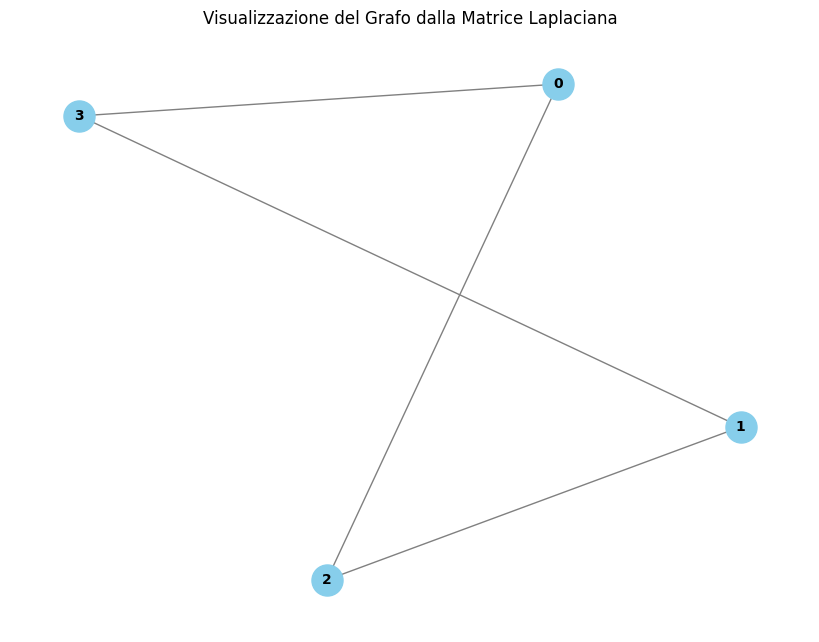

In [16]:
drawGraph(l)

In [19]:
executeQpe(laplacian=quadrato,precision=5,trotterSteps=3, edgesToRemove=[0], targetThreshold=None, showCircuit=True )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=4)


░ ┌───┐ ░ ┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─┐            
 q_0: ────────────────░─┤ H ├─░─┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤M├────────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         │└╥┘┌─┐         
 q_1: ────────────────░─┤ H ├─░─┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├─╫─┤M├─────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         │ ║ └╥┘┌─┐      
 q_2: ────────────────░─┤ H ├─░─┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2 qft_dg ├─╫──╫─┤M├──────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         │ ║  ║ └╥┘┌─┐   
 q_3: ────────────────░─┤ H ├─░─┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├─╫──╫──╫─┤M├───
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         │ ║  ║  ║ └╥┘┌─┐
 q_4: ────────────────░─┤ H ├─░─┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├─╫──╫──╫──╫─┤M├
      ┌───┐           ░ └───┘ ░ │         ││         ││         ││         ││         │└─────────┘ ║  ║  ║  ║ └╥┘
 q_5: ┤ H ├──■────────░───────░─┤5        ├┤5        ├┤5        ├┤5        ├┤5        ├────────────╫──╫──╫──╫──╫─
      ├───┤  │        ░       ░ │         ││         ││         ││         ││         │            ║  ║  ║  ║  ║ 
 q_6: ┤ H ├──┼────■───░───────░─┤6  U^2^0 ├┤6  U^2^1 ├┤6  U^2^2 ├┤6  U^2^3 ├┤6  U^2^4 ├────────────╫──╫──╫──╫──╫─
      └───┘┌─┴─┐  │   ░       ░ │         ││         ││         ││         ││         │            ║  ║  ║  ║  ║ 
 q_7: ─────┤ X ├──┼───░───────░─┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├────────────╫──╫──╫──╫──╫─
           └───┘┌─┴─┐ ░       ░ │         ││         ││         ││         ││         │            ║  ║  ║  ║  ║ 
 q_8: ──────────┤ X ├─░───────░─┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├────────────╫──╫──╫──╫──╫─
                └───┘ ░       ░ │         ││         ││         ││         ││         │            ║  ║  ║  ║  ║ 
 q_9: ────────────────░───────░─┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├────────────╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │            ║  ║  ║  ║  ║ 
q_10: ────────────────░───────░─┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├────────────╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │            ║  ║  ║  ║  ║ 
q_11: ────────────────░───────░─┤11       ├┤11       ├┤11       ├┤11       ├┤11       ├────────────╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │            ║  ║  ║  ║  ║ 
q_12: ────────────────░───────░─┤12       ├┤12       ├┤12       ├┤12       ├┤12       ├────────────╫──╫──╫──╫──╫─
                      ░       ░ └─────────┘└─────────┘└─────────┘└─────────┘└─────────┘            ║  ║  ║  ║  ║ 
 c: 5/═════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                                                                   0  1  2  3  4

{'11000': 2, '10001': 1, '01000': 1, '00100': 4, '10110': 1, '00110': 2, '11111': 2, '01010': 1, '11100': 7, '00011': 1, '00001': 1, '00101': 2561, '11011': 2485, '11010': 4, '11101': 2, '10000': 2454, '00000': 2471}
Tempo di esecuzione: 2.178102 secondi
Risultati ordinati per frequenza (primi 4 risultati):
Bitstring: 00101 | Conteggi: 2561 | Autovalore Stimato: 0.6250
Bitstring: 11011 | Conteggi: 2485 | Autovalore Stimato: 3.3750
Bitstring: 00000 | Conteggi: 2471 | Autovalore Stimato: 0.0000
Bitstring: 10000 | Conteggi: 2454 | Autovalore Stimato: 2.0000


In [25]:
path = generateSparseGraphWithNNodes(4)

path= removeEdge(path, 3,0)

Grafo generato: N=4, Grado Max=2 (Limite=2), Connesso=True


In [ ]:
executeQpe(laplacian=l,precision=5,trotterSteps=5, edgesToRemove=[0], targetThreshold=0.7, showCircuit=True )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=4)


░ ┌───┐ ░ ┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────┐ ░ ┌─┐            
 q_0: ────────────────░─┤ H ├─░─┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0    ├─░─┤M├────────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░ └╥┘┌─┐         
 q_1: ────────────────░─┤ H ├─░─┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1    ├─░──╫─┤M├─────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║ └╥┘┌─┐      
 q_2: ────────────────░─┤ H ├─░─┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2 qft_dg ├┤2    ├─░──╫──╫─┤M├──────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║  ║ └╥┘┌─┐   
 q_3: ────────────────░─┤ H ├─░─┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3    ├─░──╫──╫──╫─┤M├───
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║  ║  ║ └╥┘┌─┐
 q_4: ────────────────░─┤ H ├─░─┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4    ├─░──╫──╫──╫──╫─┤M├
      ┌───┐           ░ └───┘ ░ │         ││         ││         ││         ││         │└─────────┘│     │ ░  ║  ║  ║  ║ └╥┘
 q_5: ┤ H ├──■────────░───────░─┤5        ├┤5        ├┤5        ├┤5        ├┤5        ├───────────┤5    ├─░──╫──╫──╫──╫──╫─
      ├───┤  │        ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_6: ┤ H ├──┼────■───░───────░─┤6  U^2^0 ├┤6  U^2^1 ├┤6  U^2^2 ├┤6  U^2^3 ├┤6  U^2^4 ├───────────┤6  G ├─░──╫──╫──╫──╫──╫─
      └───┘┌─┴─┐  │   ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_7: ─────┤ X ├──┼───░───────░─┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├───────────┤7    ├─░──╫──╫──╫──╫──╫─
           └───┘┌─┴─┐ ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_8: ──────────┤ X ├─░───────░─┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├───────────┤8    ├─░──╫──╫──╫──╫──╫─
                └───┘ ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_9: ────────────────░───────░─┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├───────────┤9    ├─░──╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_10: ────────────────░───────░─┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├───────────┤10   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_11: ────────────────░───────░─┤11       ├┤11       ├┤11       ├┤11       ├┤11       ├───────────┤11   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_12: ────────────────░───────░─┤12       ├┤12       ├┤12       ├┤12       ├┤12       ├───────────┤12   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ └─────────┘└─────────┘└─────────┘└─────────┘└─────────┘           └─────┘ ░  ║  ║  ║  ║  ║ 
 c: 5/═══════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                                                                             0  1  2  3  4

{'00010': 1, '00100': 5, '00101': 94}
Tempo di esecuzione: 70.397748 secondi
Risultati ordinati per frequenza (primi 4 risultati):
Bitstring: 00101 | Conteggi: 94 | Autovalore Stimato: 0.6250
Bitstring: 00100 | Conteggi: 5 | Autovalore Stimato: 0.5000
Bitstring: 00010 | Conteggi: 1 | Autovalore Stimato: 0.2500


In [ ]:
executeQpe(laplacian=l,precision=5,trotterSteps=3, edgesToRemove=[1], targetThreshold=0.7, showCircuit=True )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=4)


░ ┌───┐ ░ ┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────┐ ░ ┌─┐            
 q_0: ────────────────░─┤ H ├─░─┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0    ├─░─┤M├────────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░ └╥┘┌─┐         
 q_1: ────────────────░─┤ H ├─░─┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1    ├─░──╫─┤M├─────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║ └╥┘┌─┐      
 q_2: ────────────────░─┤ H ├─░─┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2 qft_dg ├┤2    ├─░──╫──╫─┤M├──────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║  ║ └╥┘┌─┐   
 q_3: ────────────────░─┤ H ├─░─┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3    ├─░──╫──╫──╫─┤M├───
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║  ║  ║ └╥┘┌─┐
 q_4: ────────────────░─┤ H ├─░─┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4    ├─░──╫──╫──╫──╫─┤M├
      ┌───┐           ░ └───┘ ░ │         ││         ││         ││         ││         │└─────────┘│     │ ░  ║  ║  ║  ║ └╥┘
 q_5: ┤ H ├──■────────░───────░─┤5        ├┤5        ├┤5        ├┤5        ├┤5        ├───────────┤5    ├─░──╫──╫──╫──╫──╫─
      ├───┤  │        ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_6: ┤ H ├──┼────■───░───────░─┤6  U^2^0 ├┤6  U^2^1 ├┤6  U^2^2 ├┤6  U^2^3 ├┤6  U^2^4 ├───────────┤6  G ├─░──╫──╫──╫──╫──╫─
      └───┘┌─┴─┐  │   ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_7: ─────┤ X ├──┼───░───────░─┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├───────────┤7    ├─░──╫──╫──╫──╫──╫─
           └───┘┌─┴─┐ ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_8: ──────────┤ X ├─░───────░─┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├───────────┤8    ├─░──╫──╫──╫──╫──╫─
                └───┘ ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_9: ────────────────░───────░─┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├───────────┤9    ├─░──╫──╫──╫──╫──╫─
      ┌───┐           ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_10: ┤ X ├───────────░───────░─┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├───────────┤10   ├─░──╫──╫──╫──╫──╫─
      └───┘           ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_11: ────────────────░───────░─┤11       ├┤11       ├┤11       ├┤11       ├┤11       ├───────────┤11   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_12: ────────────────░───────░─┤12       ├┤12       ├┤12       ├┤12       ├┤12       ├───────────┤12   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ └─────────┘└─────────┘└─────────┘└─────────┘└─────────┘           └─────┘ ░  ║  ║  ║  ║  ║ 
 c: 5/═══════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                                                                             0  1  2  3  4

{'00101': 100}
Tempo di esecuzione: 37.410308 secondi
Risultati ordinati per frequenza (primi 4 risultati):
Bitstring: 00101 | Conteggi: 100 | Autovalore Stimato: 0.6250


In [ ]:
executeQpe(laplacian=l,precision=5,trotterSteps=3, edgesToRemove=[2], targetThreshold=0.7, showCircuit=True )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=4)


░ ┌───┐ ░ ┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────┐ ░ ┌─┐            
 q_0: ────────────────░─┤ H ├─░─┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0    ├─░─┤M├────────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░ └╥┘┌─┐         
 q_1: ────────────────░─┤ H ├─░─┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1    ├─░──╫─┤M├─────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║ └╥┘┌─┐      
 q_2: ────────────────░─┤ H ├─░─┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2 qft_dg ├┤2    ├─░──╫──╫─┤M├──────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║  ║ └╥┘┌─┐   
 q_3: ────────────────░─┤ H ├─░─┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3    ├─░──╫──╫──╫─┤M├───
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║  ║  ║ └╥┘┌─┐
 q_4: ────────────────░─┤ H ├─░─┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4    ├─░──╫──╫──╫──╫─┤M├
      ┌───┐           ░ └───┘ ░ │         ││         ││         ││         ││         │└─────────┘│     │ ░  ║  ║  ║  ║ └╥┘
 q_5: ┤ H ├──■────────░───────░─┤5        ├┤5        ├┤5        ├┤5        ├┤5        ├───────────┤5    ├─░──╫──╫──╫──╫──╫─
      ├───┤  │        ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_6: ┤ H ├──┼────■───░───────░─┤6  U^2^0 ├┤6  U^2^1 ├┤6  U^2^2 ├┤6  U^2^3 ├┤6  U^2^4 ├───────────┤6  G ├─░──╫──╫──╫──╫──╫─
      └───┘┌─┴─┐  │   ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_7: ─────┤ X ├──┼───░───────░─┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├───────────┤7    ├─░──╫──╫──╫──╫──╫─
           └───┘┌─┴─┐ ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_8: ──────────┤ X ├─░───────░─┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├───────────┤8    ├─░──╫──╫──╫──╫──╫─
      ┌───┐     └───┘ ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_9: ┤ X ├───────────░───────░─┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├───────────┤9    ├─░──╫──╫──╫──╫──╫─
      └───┘           ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_10: ────────────────░───────░─┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├───────────┤10   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_11: ────────────────░───────░─┤11       ├┤11       ├┤11       ├┤11       ├┤11       ├───────────┤11   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_12: ────────────────░───────░─┤12       ├┤12       ├┤12       ├┤12       ├┤12       ├───────────┤12   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ └─────────┘└─────────┘└─────────┘└─────────┘└─────────┘           └─────┘ ░  ║  ║  ║  ║  ║ 
 c: 5/═══════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                                                                             0  1  2  3  4

{'00101': 100}
Tempo di esecuzione: 36.485658 secondi
Risultati ordinati per frequenza (primi 4 risultati):
Bitstring: 00101 | Conteggi: 100 | Autovalore Stimato: 0.6250


In [ ]:
executeQpe(laplacian=l,precision=5,trotterSteps=3, edgesToRemove=[3], targetThreshold=0.7, showCircuit=True )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=4)


░ ┌───┐ ░ ┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────┐ ░ ┌─┐            
 q_0: ────────────────░─┤ H ├─░─┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0    ├─░─┤M├────────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░ └╥┘┌─┐         
 q_1: ────────────────░─┤ H ├─░─┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1    ├─░──╫─┤M├─────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║ └╥┘┌─┐      
 q_2: ────────────────░─┤ H ├─░─┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2 qft_dg ├┤2    ├─░──╫──╫─┤M├──────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║  ║ └╥┘┌─┐   
 q_3: ────────────────░─┤ H ├─░─┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3    ├─░──╫──╫──╫─┤M├───
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││     │ ░  ║  ║  ║ └╥┘┌─┐
 q_4: ────────────────░─┤ H ├─░─┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4    ├─░──╫──╫──╫──╫─┤M├
      ┌───┐           ░ └───┘ ░ │         ││         ││         ││         ││         │└─────────┘│     │ ░  ║  ║  ║  ║ └╥┘
 q_5: ┤ H ├──■────────░───────░─┤5        ├┤5        ├┤5        ├┤5        ├┤5        ├───────────┤5    ├─░──╫──╫──╫──╫──╫─
      ├───┤  │        ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_6: ┤ H ├──┼────■───░───────░─┤6  U^2^0 ├┤6  U^2^1 ├┤6  U^2^2 ├┤6  U^2^3 ├┤6  U^2^4 ├───────────┤6  G ├─░──╫──╫──╫──╫──╫─
      └───┘┌─┴─┐  │   ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_7: ─────┤ X ├──┼───░───────░─┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├───────────┤7    ├─░──╫──╫──╫──╫──╫─
           └───┘┌─┴─┐ ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_8: ──────────┤ X ├─░───────░─┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├───────────┤8    ├─░──╫──╫──╫──╫──╫─
      ┌───┐     └───┘ ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
 q_9: ┤ X ├───────────░───────░─┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├───────────┤9    ├─░──╫──╫──╫──╫──╫─
      ├───┤           ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_10: ┤ X ├───────────░───────░─┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├───────────┤10   ├─░──╫──╫──╫──╫──╫─
      └───┘           ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_11: ────────────────░───────░─┤11       ├┤11       ├┤11       ├┤11       ├┤11       ├───────────┤11   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ │         ││         ││         ││         ││         │           │     │ ░  ║  ║  ║  ║  ║ 
q_12: ────────────────░───────░─┤12       ├┤12       ├┤12       ├┤12       ├┤12       ├───────────┤12   ├─░──╫──╫──╫──╫──╫─
                      ░       ░ └─────────┘└─────────┘└─────────┘└─────────┘└─────────┘           └─────┘ ░  ║  ║  ║  ║  ║ 
 c: 5/═══════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩═
                                                                                                             0  1  2  3  4

{'00101': 100}
Tempo di esecuzione: 37.324784 secondi
Risultati ordinati per frequenza (primi 4 risultati):
Bitstring: 00101 | Conteggi: 100 | Autovalore Stimato: 0.6250


In [12]:
l_paw = np.array([[ 2, -1, -1,  0],
                  [-1,  2, -1,  0],
                  [-1, -1,  3, -1],
                  [ 0,  0, -1,  1]])

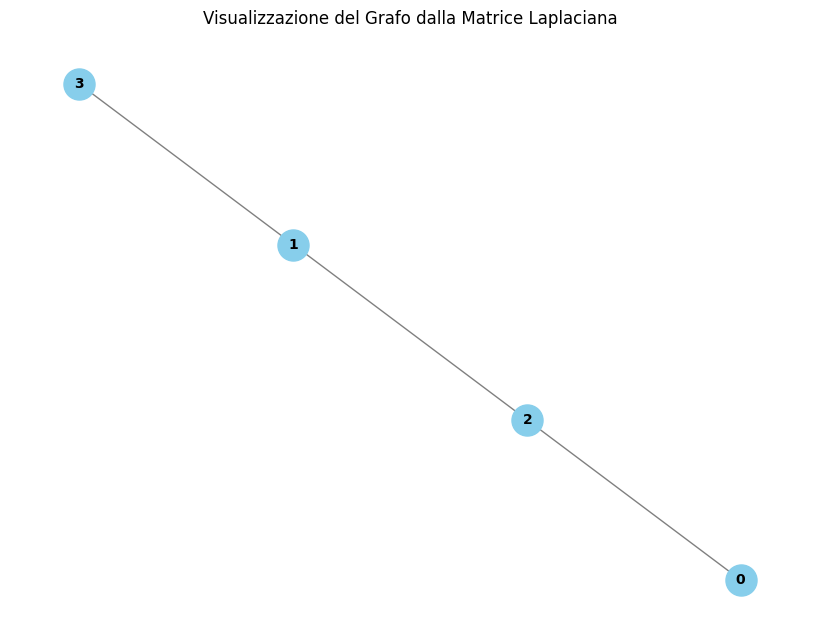

In [32]:
drawGraph(path)

In [34]:
printEigenValues(path)

Eigenvalues:
[0.     0.5858 2.     3.4142]


In [37]:
executeQpe(laplacian=path,precision=6,trotterSteps=3, edgesToRemove=[], targetThreshold=None, showCircuit=True )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=4)


░ ┌───┐ ░ ┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─┐               
 q_0: ────────────────░─┤ H ├─░─┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤M├───────────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         │└╥┘┌─┐            
 q_1: ────────────────░─┤ H ├─░─┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├─╫─┤M├────────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         │ ║ └╥┘┌─┐         
 q_2: ────────────────░─┤ H ├─░─┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├─╫──╫─┤M├─────────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││  qft_dg │ ║  ║ └╥┘┌─┐      
 q_3: ────────────────░─┤ H ├─░─┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├─╫──╫──╫─┤M├──────
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         │ ║  ║  ║ └╥┘┌─┐   
 q_4: ────────────────░─┤ H ├─░─┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├─╫──╫──╫──╫─┤M├───
                      ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         │ ║  ║  ║  ║ └╥┘┌─┐
 q_5: ────────────────░─┤ H ├─░─┤5  U^2^0 ├┤5  U^2^1 ├┤5  U^2^2 ├┤5  U^2^3 ├┤5  U^2^4 ├┤5  U^2^5 ├┤5        ├─╫──╫──╫──╫──╫─┤M├
      ┌───┐           ░ └───┘ ░ │         ││         ││         ││         ││         ││         │└─────────┘ ║  ║  ║  ║  ║ └╥┘
 q_6: ┤ H ├──■────────░───────░─┤6        ├┤6        ├┤6        ├┤6        ├┤6        ├┤6        ├────────────╫──╫──╫──╫──╫──╫─
      ├───┤  │        ░       ░ │         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║ 
 q_7: ┤ H ├──┼────■───░───────░─┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├────────────╫──╫──╫──╫──╫──╫─
      └───┘┌─┴─┐  │   ░       ░ │         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║ 
 q_8: ─────┤ X ├──┼───░───────░─┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├────────────╫──╫──╫──╫──╫──╫─
           └───┘┌─┴─┐ ░       ░ │         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║ 
 q_9: ──────────┤ X ├─░───────░─┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├────────────╫──╫──╫──╫──╫──╫─
                └───┘ ░ ┌───┐ ░ │         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║ 
q_10: ────────────────░─┤ X ├─░─┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├────────────╫──╫──╫──╫──╫──╫─
                      ░ └───┘ ░ └─────────┘└─────────┘└─────────┘└─────────┘└─────────┘└─────────┘            ║  ║  ║  ║  ║  ║ 
 c: 6/════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩══╩═
                                                                                                              0  1  2  3  4  5

{'010110': 1, '010011': 1, '010000': 3, '111001': 1, '011111': 1, '111000': 2, '101011': 1, '001010': 2513, '000000': 2479, '010101': 1, '110010': 1, '110110': 2380, '100000': 2515, '001011': 13, '110111': 20, '110101': 18, '001100': 6, '000101': 1, '001001': 28, '110100': 5, '111011': 2, '000110': 2, '001000': 6}
Tempo di esecuzione: 51.323878 secondi
Risultati ordinati per frequenza (primi 4 risultati):
Bitstring: 100000 | Conteggi: 2515 | Autovalore Stimato: 2.0000
Bitstring: 001010 | Conteggi: 2513 | Autovalore Stimato: 0.6250
Bitstring: 000000 | Conteggi: 2479 | Autovalore Stimato: 0.0000
Bitstring: 110110 | Conteggi: 2380 | Autovalore Stimato: 3.3750


In [38]:
executeQpe(laplacian=generateSparseGraphWithNNodes(8),precision=7,trotterSteps=4, edgesToRemove=[], targetThreshold=None, showCircuit=True )

Grafo generato: N=8, Grado Max=3 (Limite=3), Connesso=True
Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)


░ ┌───┐ ░ ┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─────────┐┌─┐                  
 q_0: ─────────────────────░─┤ H ├─░─┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤M├──────────────────
                           ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         ││         │└╥┘┌─┐               
 q_1: ─────────────────────░─┤ H ├─░─┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├─╫─┤M├───────────────
                           ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         ││         │ ║ └╥┘┌─┐            
 q_2: ─────────────────────░─┤ H ├─░─┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├┤2        ├─╫──╫─┤M├────────────
                           ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         ││         │ ║  ║ └╥┘┌─┐         
 q_3: ─────────────────────░─┤ H ├─░─┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3        ├┤3 qft_dg ├─╫──╫──╫─┤M├─────────
                           ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         ││         │ ║  ║  ║ └╥┘┌─┐      
 q_4: ─────────────────────░─┤ H ├─░─┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├┤4        ├─╫──╫──╫──╫─┤M├──────
                           ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         ││         │ ║  ║  ║  ║ └╥┘┌─┐   
 q_5: ─────────────────────░─┤ H ├─░─┤5        ├┤5        ├┤5        ├┤5        ├┤5        ├┤5        ├┤5        ├┤5        ├─╫──╫──╫──╫──╫─┤M├───
                           ░ ├───┤ ░ │         ││         ││         ││         ││         ││         ││         ││         │ ║  ║  ║  ║  ║ └╥┘┌─┐
 q_6: ─────────────────────░─┤ H ├─░─┤6        ├┤6        ├┤6        ├┤6        ├┤6        ├┤6        ├┤6        ├┤6        ├─╫──╫──╫──╫──╫──╫─┤M├
      ┌───┐                ░ └───┘ ░ │   U^2^0 ││   U^2^1 ││   U^2^2 ││   U^2^3 ││   U^2^4 ││   U^2^5 ││   U^2^6 │└─────────┘ ║  ║  ║  ║  ║  ║ └╥┘
 q_7: ┤ H ├──■─────────────░───────░─┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├┤7        ├────────────╫──╫──╫──╫──╫──╫──╫─
      ├───┤  │             ░       ░ │         ││         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║  ║ 
 q_8: ┤ H ├──┼────■────────░───────░─┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├┤8        ├────────────╫──╫──╫──╫──╫──╫──╫─
      ├───┤  │    │        ░       ░ │         ││         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║  ║ 
 q_9: ┤ H ├──┼────┼────■───░───────░─┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├┤9        ├────────────╫──╫──╫──╫──╫──╫──╫─
      └───┘┌─┴─┐  │    │   ░       ░ │         ││         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║  ║ 
q_10: ─────┤ X ├──┼────┼───░───────░─┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├┤10       ├────────────╫──╫──╫──╫──╫──╫──╫─
           └───┘┌─┴─┐  │   ░       ░ │         ││         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║  ║ 
q_11: ──────────┤ X ├──┼───░───────░─┤11       ├┤11       ├┤11       ├┤11       ├┤11       ├┤11       ├┤11       ├────────────╫──╫──╫──╫──╫──╫──╫─
                └───┘┌─┴─┐ ░       ░ │         ││         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║  ║ 
q_12: ───────────────┤ X ├─░───────░─┤12       ├┤12       ├┤12       ├┤12       ├┤12       ├┤12       ├┤12       ├────────────╫──╫──╫──╫──╫──╫──╫─
                     └───┘ ░ ┌───┐ ░ │         ││         ││         ││         ││         ││         ││         │            ║  ║  ║  ║  ║  ║  ║ 
q_13: ─────────────────────░─┤ X ├─░─┤13       ├┤13       

{'1111011': 1, '1100110': 3, '1000101': 2, '1001011': 1, '1111000': 2, '1111001': 1, '1001010': 1, '1101011': 2, '1111101': 3, '0110100': 4, '1011111': 2, '1110001': 1, '1111110': 1, '1000100': 1, '0110111': 5, '1110000': 1, '1011000': 4, '1101000': 1, '1010101': 6, '1110101': 1, '1101111': 1, '0110011': 2, '0000101': 14, '1100101': 4, '1001101': 2, '1111111': 3, '1111100': 2, '1000010': 5, '0011011': 3, '0101000': 18, '0011001': 5, '0100101': 7, '1000000': 9, '1110111': 1, '0101011': 859, '0111001': 17, '0001010': 14, '0101110': 9, '0101100': 68, '0101010': 229, '0001001': 49, '1001001': 4, '0111110': 59, '1001111': 6, '1010001': 118, '1011010': 4, '0010101': 10, '0100001': 852, '0000111': 201, '0100100': 16, '1110011': 2, '0001110': 65, '1011001': 5, '0010000': 378, '0111010': 21, '1100100': 1236, '0100110': 12, '0100000': 60, '0000011': 7, '0111111': 18, '0010110': 5, '1000001': 7, '0111101': 539, '0001000': 830, '1010110': 6, '1010011': 57, '1100001': 1, '1010111': 5, '0001100': 18

In [31]:
l8 = generateSparseGraphWithNNodes(8)

l8 = addEdge(l8, 4,6)

l8 = addEdge(l8, 0,7)

l8plus = generateSparseGraphWithNNodes(8)

l8plus = addEdge(l8plus, 4,6)

l8plus = addEdge(l8plus, 0,7)

l8plus = addEdge(l8plus, 3,7)


Grafo generato: N=8, Grado Max=3 (Limite=3), Connesso=True
Grafo generato: N=8, Grado Max=3 (Limite=3), Connesso=True


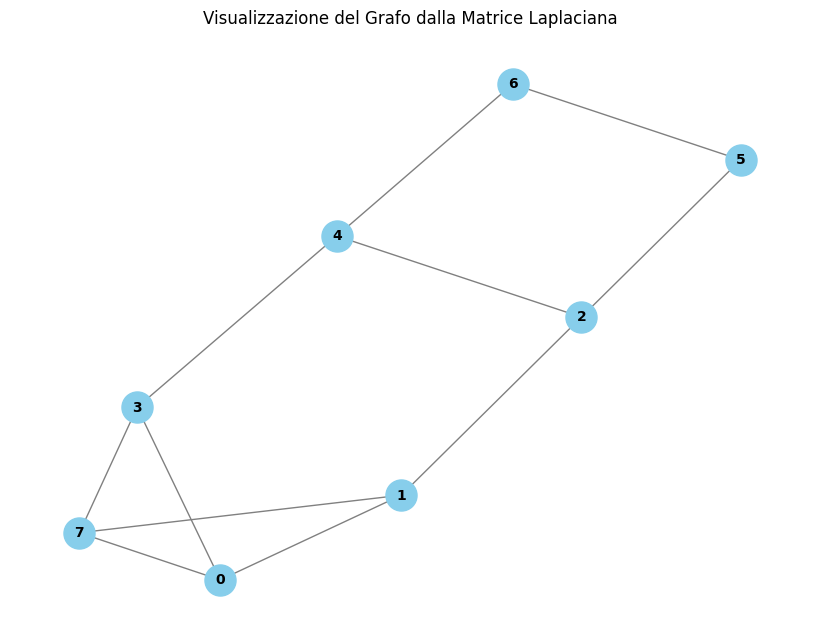

In [32]:
drawGraph(l8plus)

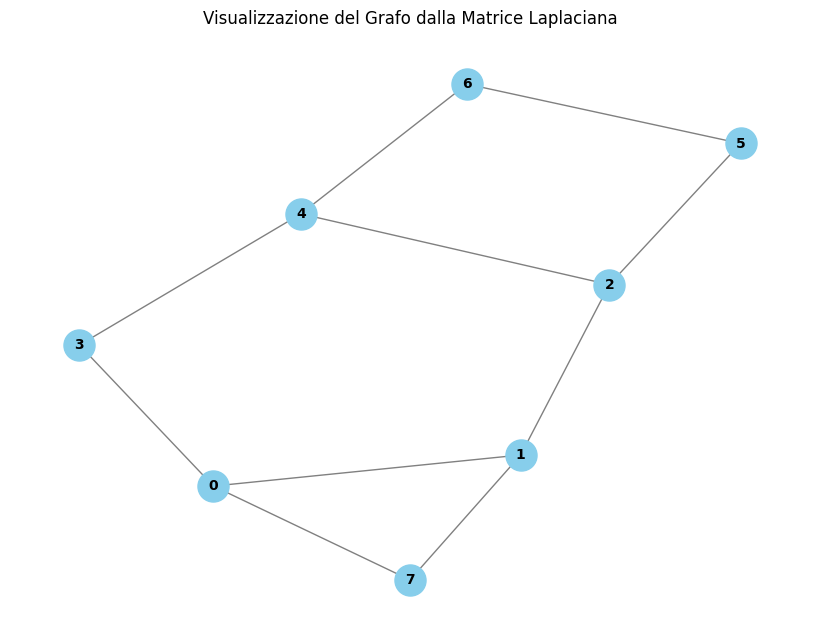

In [33]:
drawGraph(l8)




In [34]:
executeQpe(laplacian=l8plus,precision=7,trotterSteps=4, edgesToRemove=[8], targetThreshold=None, showCircuit=False )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)
{'0101010': 1, '0011110': 1, '1001111': 1, '1011000': 1, '0100110': 1, '0000010': 2, '0100010': 1, '1101111': 2, '1101101': 2, '0101110': 11, '1101000': 1, '1100111': 1, '0000001': 1, '0111110': 2, '0100000': 6, '1000111': 2, '0010010': 2, '1111100': 1, '1011100': 1, '0101101': 4, '0110011': 5, '1100001': 20, '1000100': 1, '0011000': 1, '0101100': 2, '0100111': 1, '1100010': 5, '1000101': 1, '1011101': 6, '1101110': 1, '0001010': 2, '0010110': 1, '0010001': 7, '0110010': 28, '1010000': 1, '0111010': 1291, '0111100': 1, '0001000': 4, '0110111': 1, '1111101': 2, '0000011': 1, '1001110': 1, '1001100': 3, '1100110': 2, '0001100': 32, '1001000': 3, '0011111': 1243, '1011110': 8, '0001111': 17, '0110101': 2, '0110110': 1, '1001011': 5, '1011111': 32, '1001101': 1, '0010100': 2, '0000111': 1, '0001011': 5, '1100101': 2, '1101011': 3, '1100000': 1163, '0111001': 2, '1101100': 1, '1101001': 4, '0110000

In [26]:
executeQpe(laplacian=l8plus,precision=7,trotterSteps=5, edgesToRemove=[1], targetThreshold=None, showCircuit=False )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)
{'1110000': 1, '1001110': 24, '1011001': 1, '0010110': 5, '0011000': 1, '1000001': 7, '1011000': 1, '1101110': 1, '0001110': 6, '0001100': 10, '1000000': 2, '1001010': 19, '0000110': 2, '0000010': 2, '0011001': 2, '0101111': 9, '1110011': 1, '1000101': 23, '0000111': 7, '0101110': 19, '0111011': 4, '0111101': 5, '1110111': 1, '1010101': 5, '1010111': 2, '0111111': 3, '1000100': 8, '0010111': 1245, '1011101': 1, '0100010': 4, '0111001': 35, '0010101': 3, '0100011': 3, '0100100': 24, '1111111': 1, '0111100': 6, '0111010': 13, '1010000': 929, '0001000': 29, '0110010': 5, '0100001': 3, '1100001': 1, '0000100': 3, '1001101': 21, '0011111': 4, '0101101': 53, '1000010': 7, '1010001': 54, '0110000': 7, '1010011': 12, '0001011': 33, '0001001': 94, '0101001': 17, '1111000': 1, '0101010': 52, '0001111': 1, '0110101': 11, '0100101': 1207, '0000011': 2, '1010010': 12, '1001100': 13, '0101000': 10, '1100110

In [28]:
executeQpe(laplacian=l8plus,precision=7,trotterSteps=6, edgesToRemove=[1], targetThreshold=None, showCircuit=False )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)
{'1000000': 1, '0010101': 1, '1110010': 1, '0011110': 3, '1111001': 2, '1000100': 2, '0011010': 1, '1010111': 2, '0111111': 2, '1011001': 1, '1010101': 2, '1011000': 3, '0100010': 4, '0111011': 2, '0111101': 2, '0011111': 1, '1010110': 3, '1011110': 3, '0000110': 2, '1001101': 11, '0100100': 10, '0100011': 4, '0011000': 7, '1000010': 4, '1011100': 1, '0101101': 61, '0110011': 5, '1010001': 42, '0111001': 19, '0101111': 17, '0000011': 2, '1001100': 11, '1001110': 25, '0101000': 9, '0001100': 19, '0110101': 2, '0001111': 4, '0011101': 1, '0000101': 1, '1000011': 2, '0000000': 1167, '0110001': 4, '0101110': 22, '0000111': 6, '1001000': 55, '0010100': 1, '1000110': 27, '1000111': 1074, '0110000': 8, '0010010': 2, '1011010': 2, '0011011': 1, '1010011': 9, '0001011': 40, '0001001': 104, '0110110': 11, '1001011': 13, '1000101': 8, '1010100': 4, '0101010': 33, '0010000': 4, '0100110': 12, '0010011': 2

In [14]:
executeQpe(laplacian=l8,precision=7,trotterSteps=3, edgesToRemove=[], targetThreshold=None, showCircuit=False )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)
{'1111111': 1, '1010011': 1, '1010111': 1, '0100111': 2, '1110111': 1, '1110101': 2, '1010100': 5, '0101100': 8, '1010101': 1, '0001000': 8, '1110110': 1, '0111110': 3, '0101011': 4, '0100110': 3, '1110010': 3, '1111110': 1, '1110000': 7, '1101111': 6, '0000100': 2, '1111001': 3, '0001110': 289, '0001100': 65, '1000000': 1, '0100011': 5, '1000010': 7, '0011001': 5, '0101111': 55, '1110011': 3, '1000101': 10, '0000111': 5, '1001010': 422, '0000110': 1, '1011010': 3, '0010010': 7, '0001010': 4, '1001101': 12, '0101001': 7, '1111000': 2, '0011100': 12, '0101010': 5, '0010111': 1, '1011101': 10, '0100010': 18, '0111011': 32, '0101110': 19, '1101101': 12, '1011100': 4, '0000000': 1266, '0110111': 14, '0110011': 24, '0011111': 768, '0101101': 11, '1100011': 16, '1000111': 25, '1001000': 57, '1111101': 2, '0011110': 49, '1001111': 7, '0110100': 16, '0011010': 5, '1101110': 6, '1000100': 8, '0111101':

In [15]:
executeQpe(laplacian=l8,precision=7,trotterSteps=4, edgesToRemove=[], targetThreshold=None, showCircuit=False )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)
{'1110101': 1, '0111000': 1, '0100010': 1, '1100110': 1, '1100011': 1, '1011101': 1, '1010100': 1, '1111100': 1, '0000111': 2, '0010100': 1, '1101101': 1, '0101110': 5, '0110111': 2, '1001101': 1, '0111011': 2, '1110000': 1, '1100001': 17, '0000100': 1, '0000010': 1, '1001011': 8, '1011111': 29, '0110110': 3, '0110101': 1, '0001111': 11, '0101101': 1, '0110011': 7, '1001100': 2, '0000011': 1, '1101100': 2, '1010001': 1, '0111001': 4, '0101100': 1, '1100010': 10, '0010010': 2, '0011110': 4, '1101011': 5, '1100101': 3, '0111010': 1198, '0001000': 1, '1001000': 5, '1100111': 1, '1101000': 3, '0011111': 1217, '1011110': 4, '0110100': 3, '1000000': 2, '0001001': 1, '0001011': 10, '0001101': 1166, '1100100': 2, '0110010': 27, '0001010': 3, '1101001': 4, '0110000': 54, '0001100': 41, '1101010': 1266, '1001010': 1234, '1001001': 10, '0010000': 8, '1011011': 1, '0000101': 1, '0000000': 1237, '0110001':

In [16]:
executeQpe(laplacian=l8,precision=7,trotterSteps=5, edgesToRemove=[], targetThreshold=None, showCircuit=False )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)
{'0101010': 1, '1000100': 2, '0010101': 1, '0111101': 1, '1000111': 2, '1010101': 3, '0001010': 1, '1011001': 1, '1000110': 1, '0010100': 1, '0011001': 1, '0101011': 1, '1010111': 2, '0111111': 1, '0000110': 1, '1110101': 1, '0111011': 5, '1011000': 2, '1001111': 1, '1110010': 1, '0100011': 2, '0010001': 1, '0010111': 2, '1101110': 1, '0001001': 1, '0001011': 2, '1010011': 2, '0011011': 3, '0111000': 2, '0001100': 18, '0101000': 1, '1000010': 2, '1111010': 3, '1101101': 4, '0101001': 1, '1011100': 6, '1100111': 2, '1101000': 7, '0100101': 3, '0001101': 1225, '1100100': 8, '1100110': 3, '0011010': 2, '1101011': 28, '1100101': 4, '0100001': 8, '1101100': 4, '0111001': 3, '1001101': 4, '1111111': 1, '0111100': 2, '0111010': 1280, '1010000': 2, '0000111': 1, '1110011': 1, '0101100': 1, '0100111': 1, '1100010': 15, '0010010': 1, '1011010': 8, '1101010': 1224, '1001010': 1085, '1001001': 22, '100100

In [17]:
executeQpe(laplacian=l8,precision=7,trotterSteps=6, edgesToRemove=[], targetThreshold=None, showCircuit=False )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)
{'0010000': 1, '0110101': 2, '1000010': 1, '1111011': 1, '0100110': 1, '1110000': 4, '0011001': 2, '1110011': 2, '1000100': 1, '0100010': 12, '1011101': 13, '0010111': 2, '1100110': 2, '1101110': 5, '0011010': 4, '1010101': 3, '0001110': 8, '1000000': 1, '0001100': 4, '0111101': 1, '0100011': 6, '1011010': 3, '0010010': 1, '0001111': 1, '0011111': 795, '0101101': 1, '1011100': 4, '0000000': 1168, '0110111': 2, '0110011': 5, '1001101': 10, '1000001': 2, '1011000': 5, '0101010': 1, '0011100': 23, '1110001': 1, '1100001': 12, '0100001': 21, '0110010': 20, '1000111': 12, '1001000': 8, '0111000': 4, '0101100': 2, '1100010': 5, '0011000': 5, '1111101': 1, '1101111': 2, '0101011': 1, '1111010': 1, '1100000': 61, '0100100': 3, '0110100': 2, '0011110': 220, '1001111': 4, '1100011': 4, '1001011': 188, '1110100': 1, '1010111': 3, '0111111': 4, '0111011': 26, '0101110': 1, '1101101': 5, '0010101': 4, '011

In [18]:
executeQpe(laplacian=l8,precision=7,trotterSteps=4, edgesToRemove=[], targetThreshold=None, showCircuit=False )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)
{'0011001': 1, '0100011': 2, '0111111': 1, '0111000': 1, '0101001': 1, '0000011': 1, '1001100': 1, '1000010': 1, '0000010': 1, '1001000': 3, '1100011': 1, '0010000': 7, '0011000': 1, '1100101': 1, '1101011': 3, '1000111': 1, '0011110': 8, '0100001': 2, '1101100': 2, '0111001': 1, '1100001': 23, '0000100': 1, '0111110': 2, '1110110': 1, '0100000': 2, '0111101': 2, '0001111': 6, '0010001': 5, '0110010': 21, '0101011': 2, '1011100': 1, '0110011': 9, '0101101': 1, '1001101': 1, '1101111': 1, '0101100': 2, '1100010': 3, '0010010': 3, '0000111': 1, '0001010': 4, '1111011': 1, '1001011': 11, '1011111': 23, '1100110': 1, '0001100': 21, '0101110': 5, '1101101': 2, '0100010': 3, '1000101': 1, '1011101': 5, '0001001': 1, '0001011': 9, '1000011': 1, '0000000': 1314, '0011101': 1, '0110001': 1121, '1001010': 1262, '1101010': 1236, '0010100': 1, '1000110': 1, '0000110': 2, '1100111': 1, '1101000': 2, '00100

In [ ]:
executeQpe(laplacian=l8,precision=8,trotterSteps=4, edgesToRemove=[], targetThreshold=None, showCircuit=False )

Executing QPE with Balanced Mixed State Initialization and first edge elimination (n_nodes=8)


In [ ]:
executeQpe(laplacian=l8,precision=9,trotterSteps=4, edgesToRemove=[], targetThreshold=None, showCircuit=False )

In [ ]:
executeQpe(laplacian=l8,precision=10,trotterSteps=4, edgesToRemove=[], targetThreshold=None, showCircuit=False )